# Cuaderno 2: Validación y Análisis Factorial Exploratorio 🏗️

### **1. Introducción y Configuración**

**Objetivo:** Este cuaderno inicia el proyecto de evaluación de impacto. Su propósito es cargar los datos brutos de la encuesta de egresados, aplicar un protocolo de limpieza riguroso para asegurar la calidad de los datos, y finalmente, realizar un **Análisis Factorial Exploratorio (EFA)**. Esta técnica nos permitirá descubrir la estructura latente que subyace a las respuestas de la encuesta, simplificando la complejidad de los datos para análisis futuros.

**Librerías:**
* `pandas` y `numpy`: Para la manipulación de datos.
* `factor_analyzer`: Para ejecutar el Análisis Factorial.
* `matplotlib` y `seaborn`: Para crear visualizaciones.

**Detalle del Código:** A continuación, importaremos las librerías y cargaremos el archivo de datos desde la carpeta `../datos/`.

In [ ]:
# -*- coding: utf-8 -*-

# 1. LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# Configuraciones de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. CARGA DE DATOS
# El archivo debe estar en la carpeta 'datos', que está al mismo nivel que la carpeta 'notebooks'.


try:
    data_path = '/content/DATA DEPURADA SANTO TOMAS_ESTUDIO PENSER_MAYO DE 2025.xlsx'
    df_raw = pd.read_excel(data_path)
    print("Archivo Excel cargado exitosamente.")
    print("Dimensiones del dataset:", df_raw.shape)
    print("\nPrimeras 5 filas del dataset:")
    display(df_raw.head())
except FileNotFoundError:
    print("Error: No se encontró el archivo en la ruta especificada.")
    print("Por favor, verifica que el archivo exista en la carpeta 'datos' y el nombre sea correcto.")

Archivo Excel cargado exitosamente.
Dimensiones del dataset: (1129, 143)

Primeras 5 filas del dataset:


,Marca temporal,"Consentimiento de tratamiento de datos personales\nDe acuerdo con la política de tratamiento de datos personales, se informa que la información consignada en el presente formulario será usada únicamente con fines académicos e investigativos, salvaguardando",Número de documento de identificación,Universidad,Sede o Seccional,PROGRAMA ACADEMICO,País en el cual cursó sus estudios,Ciudad en la cual cursó sus estudios (Escríbala en mayúscula y sin tildes),País de residencia actual (Escríbalo en mayúscula y sin tildes),Año de graduación,...,III.18. ¿El valor actual de sus ingresos mensuales es superior al valor de los ingresos mensuales durante su último año de estudio?,III.19. Considera Ud. que su ingreso actual es:,"III. 19.1 ¿Considera que las condiciones de su vivienda (infraestructura, ubicación, servicios básicos, entre otros) han mejorado desde que obtuvo su título universitario?","IV.20. Indique su apreciación frente a la siguiente afirmación: “La formación recibida en la universidad ha sido un aspecto determinante en el mejoramiento de mi calidad de vida"".",IV. 21. Indique el nivel de incidencia de la formación recibida en: [El mejoramiento de mis ingresos],IV. 21. Indique el nivel de incidencia de la formación recibida en: [El acceso a oportunidades de empleo],"IV. 21. Indique el nivel de incidencia de la formación recibida en: [El mejoramiento de las condiciones de la vivienda en términos de infraestructura o ubicación (por ejemplo, se trasladó a una mejor zona de la ciudad)]",IV. 21. Indique el nivel de incidencia de la formación recibida en: [El acceso a servicios de salud],IV. 21. Indique el nivel de incidencia de la formación recibida en: [El acceso a servicios de recreación y deporte],IV. 21. Indique el nivel de incidencia de la formación recibida en: [El acceso a mayores niveles educativos]
0,2024-11-08 11:12:49.559000,X,1098782700,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,INGENIERÍA INDUSTRIAL,Colombia,BUCARAMANGA,COLOMBIA,2021,...,No,Suficiente (mis ingresos cubren satisfactoriam...,Sí,Totalmente de acuerdo,Alto,Muy alto,Alto,Alto,Alto,Muy alto
1,2024-11-08 11:33:45.866000,X,1100966241,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,QUÍMICA AMBIENTAL,Colombia,BUCARAMANGA,COLOMBIA,2018,...,Si,Suficiente (mis ingresos cubren satisfactoriam...,No,Ni de acuerdo ni en desacuerdo,Muy bajo,Alto,No incidió,No incidió,No incidió,No incidió
2,2024-11-08 12:43:27.649000,X,1098691859,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,Colombia,BUCARAMANGA,COLOMBIA,2024,...,Si,Muy suficiente (mis ingresos cubren mis necesi...,Sí,De acuerdo,Alto,Alto,Alto,Alto,Alto,Alto
3,2024-11-08 12:56:20.322000,X,1016042482,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,Colombia,Bucaramanga,Colombia,2019,...,No,Suficiente (mis ingresos cubren satisfactoriam...,No,De acuerdo,Alto,Alto,Alto,Alto,Alto,Alto
4,2024-11-08 14:54:08.393000,X,1094506076,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,ESPECIALIZACIÓN EN FINANZAS PÚBLICAS,Colombia,Bucaramanga,MOGOTES,2024,...,Si,Suficiente (mis ingresos cubren satisfactoriam...,No,Ni de acuerdo ni en desacuerdo,Bajo,Alto,No incidió,No incidió,No incidió,Muy bajo


### **2. Transformación de Nombres de Columna**

**Objetivo:** Renombrar las columnas largas y complejas a nombres cortos, descriptivos y fáciles de usar en Python (en formato `snake_case`).

**Detalle del Código:** Se crea un diccionario de mapeo, `column_mapping`, donde las llaves son los nombres originales y los valores son los nuevos nombres cortos. Nos enfocaremos en las **Competencias Transversales** para este análisis. Luego, se aplica esta transformación al dataframe.

In [ ]:
# Mapeo de columnas de Competencias Transversales
# Las llaves son los nombres originales del archivo Excel.
column_mapping = {
    'Marca temporal': 'marca_temporal',
    'Consentimiento de tratamiento de datos personales\nDe acuerdo con la política de tratamiento de datos personales, se informa que la información consignada en el presente formulario será usada únicamente con fines académicos e investigativos, salvaguardando': 'consentimiento_datos',
    'Número de documento de identificación': 'documento_identidad',
    'Universidad': 'universidad',
    'Sede o Seccional': 'sede',
    'PROGRAMA ACADEMICO': 'programa_academico',
    'País en el cual cursó sus estudios': 'pais_estudios',
    'Ciudad en la cual cursó sus estudios (Escríbala en mayúscula y sin tildes)': 'ciudad_estudios',
    'País  de residencia actual (Escríbalo en mayúscula y sin tildes)': 'pais_residencia',
    'Año de graduación': 'ano_graduacion',
    'I.1. ¿Se encuentra laborando actualmente? ': 'c1_1_laborando_actualmente',
    'I.2.1. Nombre de la organización': 'c1_2_1_nombre_organizacion',
    'I.2.2. Tipo de vinculación': 'c1_2_2_tipo_vinculacion',
    'I.2.3. Cargo actual': 'c1_2_3_cargo_actual',
    'I.2.4. Tipo de cargo': 'c1_2_4_tipo_cargo',
    'Indique el nivel de logro en el que la formación recibida durante sus estudios favoreció el desarrollo de las competencias profesionales, requeridas en los diferentes campos de su desempeño y pertinentes con las necesidades de los contextos locales, regio': 'c1_3_1_comp_cognitivas',
    'Indique el nivel de logro en el que la formación recibida durante sus estudios favoreció el desarrollo de las competencias profesionales, requeridas en los diferentes campos de su desempeño y pertinentes con las necesidades de los contextos locales, re2': 'c1_3_2_comp_digitales',
    'Indique el nivel de logro en el que la formación recibida durante sus estudios favoreció el desarrollo de las competencias profesionales, requeridas en los diferentes campos de su desempeño y pertinentes con las necesidades de los contextos locales, re3': 'c1_3_3_comp_ingles',
    'Indique el nivel de logro en el que la formación recibida durante sus estudios favoreció el desarrollo de las competencias profesionales, requeridas en los diferentes campos de su desempeño y pertinentes con las necesidades de los contextos locales, re4': 'c1_3_4_comp_investigativas',
    'Indique el nivel de logro en el que la formación recibida durante sus estudios favoreció el desarrollo de las competencias profesionales, requeridas en los diferentes campos de su desempeño y pertinentes con las necesidades de los contextos locales, re5': 'c1_3_5_comp_gestion_comunitaria',
    'I.4. Indique su percepción frente a la siguiente afirmación: “El programa académico del cual me gradué es pertinente con relación a las demandas del entorno social y académico” ': 'c1_4_percepcion_pertinencia',
    'I.4.I. ¿Considera que las competencias y habilidades adquiridas durante su formación universitaria han sido suficientes para enfrentar los desafíos y exigencias del entorno laboral actual?': 'c1_4_1_suficiencia_competencias',
    'I.5. ¿Ha recibido distinciones o premios? ': 'c1_5_recibio_premios',
    'I.5.1. Nombre la última distinción que recibió y la entidad que la otorga': 'c1_5_1_nombre_distincion',
    'I.5.2. Año de la distinción': 'c1_5_2_ano_distincion',
    'I.6.  ¿Usted pertenece a algún gremio, red y/o asociación científica? ': 'c1_6_pertenece_gremio',
    'I.6.1.  Nombre del gremio, red y/o asociación científica que desee destacar': 'c1_6_1_nombre_gremio',
    'I.6.2. Año de vinculación': 'c1_6_2_ano_vinculacion_gremio',
    'I.6.3.  Logros o resultados que desea destacar': 'c1_6_3_logros_gremio',
    'I.7. Una vez graduado (a) del programa, ¿ha liderado o acompañado proyectos comunitarios?': 'c1_7_lidero_proy_comunitarios',
    'I.7.1. Nombre del proyecto que desee destacar': 'c1_7_1_nombre_proy_comunitario',
    'I.7.2. Comunidad beneficiada': 'c1_7_2_comunidad_beneficiada',
    'I.7.3.  Logros o resultados que desea destacar': 'c1_7_3_logros_proy_comunitario',
    'I.8. Una vez graduado (a) del programa, ¿ha liderado o participado en proyectos de investigación?': 'c1_8_lidero_proy_investigacion',
    'I.8.1. Nombre del proyecto que desee destacar': 'c1_8_1_nombre_proy_investigacion',
    'I.8.2. Año de desarrollo ': 'c1_8_2_ano_proy_investigacion',
    'I.8.3. Logros o resultados que desea destacar': 'c1_8_3_logros_proy_investigacion',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [COMUNICACIÓN EFECTIVA: expresar con claridad, y en forma apropiada al contexto y la cultura, lo q': 'c2_9_comunicacion_efectiva',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [RELACIONES INTERPERSONALES: establecer y conservar relaciones significativas, así como ser capaz ': 'c2_9_relaciones_interpersonales',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [TOMA DE DECISIONES: evaluar distintas alternativas, teniendo en cuenta necesidades, capacidades, ': 'c2_9_toma_de_decisiones',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [SOLUCIÓN DE PROBLEMAS Y CONFLICTOS: transformar y manejar los problemas y conflictos de la vida d': 'c2_9_solucion_problemas',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [PENSAMIENTO CREATIVO: usar la razón y la “pasión” (emociones, sentimientos, intuición, fantasías ': 'c2_9_pensamiento_creativo',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [PENSAMIENTO CRÍTICO: aprender a preguntarse, investigar y no aceptar las cosas de forma crédula. ': 'c2_9_pensamiento_critico',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [MANEJO DE EMOCIONES Y SENTIMIENTOS: aprender a navegar en el mundo afectivo logrando mayor “sinto': 'c2_9_manejo_emociones',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [MANEJO DE TENSIONES Y ESTRÉS: identificar oportunamente las fuentes de tensión y estrés en la vid': 'c2_9_manejo_estres',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [MULTICULTURALES: tener conocimiento u comprensión de distintas culturas.]': 'c2_9_multiculturales',
    'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [INTERCULTURALES: buenas actitudes que se mantienen hacia otras culturas.]': 'c2_9_interculturales',
    'III.10. ¿Cuál es su edad actual? (en años)': 'c3_10_edad',
    'III.11. Rol en el hogar actual: ': 'c3_11_rol_hogar',
    'III.12. En cuanto a su nivel de responsabilidad económica en el hogar, usted se identifica como: ': 'c3_12_responsabilidad_economica',
    'III.13.  Máximo nivel de estudios alcanzado ': 'c3_13_max_nivel_estudios',
    'III.14.   Indique el número de hermanos que usted tiene: ': 'c3_14_numero_hermanos',
    'III.15.1. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_1_escolaridad_hermano_1',
    'III.15.2. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_2_escolaridad_hermano_1',
    'III.15.2. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_2_escolaridad_hermano_2',
    'III.15.3. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_3_escolaridad_hermano_1',
    'III.15.3. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_3_escolaridad_hermano_2',
    'III.15.3. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_3_escolaridad_hermano_3',
    'III.15.4. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_4_escolaridad_hermano_1',
    'III.15.4. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_4_escolaridad_hermano_2',
    'III.15.4. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_4_escolaridad_hermano_3',
    'III.15.4. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 4]': 'c3_15_4_escolaridad_hermano_4',
    'III.15.5. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_5_escolaridad_hermano_1',
    'III.15.5. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_5_escolaridad_hermano_2',
    'III.15.5. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_5_escolaridad_hermano_3',
    'III.15.5. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 4]': 'c3_15_5_escolaridad_hermano_4',
    'III.15.5. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 5]': 'c3_15_5_escolaridad_hermano_5',
    'III.15.6. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_6_escolaridad_hermano_1',
    'III.15.6. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_6_escolaridad_hermano_2',
    'III.15.6. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_6_escolaridad_hermano_3',
    'III.15.6. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 4]': 'c3_15_6_escolaridad_hermano_4',
    'III.15.6. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 5]': 'c3_15_6_escolaridad_hermano_5',
    'III.15.6. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 6]': 'c3_15_6_escolaridad_hermano_6',
    'III.15.7. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_7_escolaridad_hermano_1',
    'III.15.7. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_7_escolaridad_hermano_2',
    'III.15.7. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_7_escolaridad_hermano_3',
    'III.15.7. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 4]': 'c3_15_7_escolaridad_hermano_4',
    'III.15.7. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 5]': 'c3_15_7_escolaridad_hermano_5',
    'III.15.7. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 6]': 'c3_15_7_escolaridad_hermano_6',
    'III.15.7. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 7]': 'c3_15_7_escolaridad_hermano_7',
    'III.15.8. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_8_escolaridad_hermano_1',
    'III.15.8. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_8_escolaridad_hermano_2',
    'III.15.8. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_8_escolaridad_hermano_3',
    'III.15.8. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 4]': 'c3_15_8_escolaridad_hermano_4',
    'III.15.8. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 5]': 'c3_15_8_escolaridad_hermano_5',
    'III.15.8. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 6]': 'c3_15_8_escolaridad_hermano_6',
    'III.15.8. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 7]': 'c3_15_8_escolaridad_hermano_7',
    'III.15.8. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 8]': 'c3_15_8_escolaridad_hermano_8',
    'III.15.9. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_9_escolaridad_hermano_1',
    'III.15.9. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_9_escolaridad_hermano_2',
    'III.15.9. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_9_escolaridad_hermano_3',
    'III.15.9. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 4]': 'c3_15_9_escolaridad_hermano_4',
    'III.15.9. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 5]': 'c3_15_9_escolaridad_hermano_5',
    'III.15.9. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 6]': 'c3_15_9_escolaridad_hermano_6',
    'III.15.9. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 7]': 'c3_15_9_escolaridad_hermano_7',
    'III.15.9. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 8]': 'c3_15_9_escolaridad_hermano_8',
    'III.15.9. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 9]': 'c3_15_9_escolaridad_hermano_9',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_10_escolaridad_hermano_1',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_10_escolaridad_hermano_2',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_10_escolaridad_hermano_3',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 4]': 'c3_15_10_escolaridad_hermano_4',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 5]': 'c3_15_10_escolaridad_hermano_5',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 6]': 'c3_15_10_escolaridad_hermano_6',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 7]': 'c3_15_10_escolaridad_hermano_7',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 8]': 'c3_15_10_escolaridad_hermano_8',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 9]': 'c3_15_10_escolaridad_hermano_9',
    'III.15.10. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 10]': 'c3_15_10_escolaridad_hermano_10',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_11_escolaridad_hermano_1',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_11_escolaridad_hermano_2',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_11_escolaridad_hermano_3',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 4]': 'c3_15_11_escolaridad_hermano_4',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 5]': 'c3_15_11_escolaridad_hermano_5',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 6]': 'c3_15_11_escolaridad_hermano_6',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 7]': 'c3_15_11_escolaridad_hermano_7',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 8]': 'c3_15_11_escolaridad_hermano_8',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 9]': 'c3_15_11_escolaridad_hermano_9',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 10]': 'c3_15_11_escolaridad_hermano_10',
    'III.15.11. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 11]': 'c3_15_11_escolaridad_hermano_11',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 1]': 'c3_15_12_escolaridad_hermano_1',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 2]': 'c3_15_12_escolaridad_hermano_2',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 3]': 'c3_15_12_escolaridad_hermano_3',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 4]': 'c3_15_12_escolaridad_hermano_4',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 5]': 'c3_15_12_escolaridad_hermano_5',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 6]': 'c3_15_12_escolaridad_hermano_6',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 7]': 'c3_15_12_escolaridad_hermano_7',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 8]': 'c3_15_12_escolaridad_hermano_8',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 9]': 'c3_15_12_escolaridad_hermano_9',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 10]': 'c3_15_12_escolaridad_hermano_10',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 11]': 'c3_15_12_escolaridad_hermano_11',
    'III.15.12. Nivel máximo de escolaridad alcanzado por sus hermanos  [Hermano 12]': 'c3_15_12_escolaridad_hermano_12',
    'III.16.  ¿Cuál es su posición en términos del orden de nacimiento?': 'c3_16_posicion_nacimiento',
    'III.17.  Nivel máximo de escolaridad alcanzado por sus padres  [Madre]': 'c3_17_escolaridad_madre',
    'III.17.  Nivel máximo de escolaridad alcanzado por sus padres  [Padre]': 'c3_17_escolaridad_padre',
    'III.18. ¿El valor actual de sus ingresos mensuales es superior al valor de los ingresos mensuales durante su último año de estudio? ': 'c3_18_ingresos_superiores_estudio',
    'III.19. Considera Ud. que su ingreso actual es: ': 'c3_19_suficiencia_ingreso_actual',
    'III. 19.1 ¿Considera que las condiciones de su vivienda (infraestructura, ubicación, servicios básicos, entre otros) han mejorado desde que obtuvo su título universitario?': 'c3_19_1_mejora_vivienda',
    'IV.20.  Indique su apreciación frente a la siguiente afirmación: “La formación recibida en la universidad ha sido un aspecto determinante en el mejoramiento de mi calidad de vida".  ': 'c4_20_percepcion_mejora_calidad_vida',
    'IV. 21. Indique el nivel de incidencia de la formación recibida en:  [El mejoramiento de mis ingresos]': 'c4_21_incidencia_mejora_ingresos',
    'IV. 21. Indique el nivel de incidencia de la formación recibida en:  [El acceso a oportunidades de empleo]': 'c4_21_incidencia_acceso_empleo',
    'IV. 21. Indique el nivel de incidencia de la formación recibida en:  [El mejoramiento de las condiciones de la vivienda en términos de infraestructura o ubicación (por ejemplo, se trasladó a una mejor zona de la ciudad)]': 'c4_21_incidencia_mejora_vivienda',
    'IV. 21. Indique el nivel de incidencia de la formación recibida en:  [El acceso a servicios de salud]': 'c4_21_incidencia_acceso_salud',
    'IV. 21. Indique el nivel de incidencia de la formación recibida en:  [El acceso a servicios de recreación y deporte]': 'c4_21_incidencia_acceso_recreacion',
    'IV. 21. Indique el nivel de incidencia de la formación recibida en:  [El acceso a mayores niveles educativos]': 'c4_21_incidencia_acceso_educacion'
}

# Aplicamos el renombrado al dataframe
df_renamed = df_raw.rename(columns=column_mapping)

# Creamos una lista con los nuevos nombres para usarlos fácilmente más adelante
cols_transversales = list(column_mapping.values())

print("Columnas renombradas exitosamente.")
print("\nNuevos nombres para las columnas de competencias transversales:")
print(cols_transversales)

# Verificamos que las columnas ahora existen en el nuevo dataframe
print("\nPrimeras filas del dataset con columnas renombradas:")
display(df_renamed[cols_transversales].head())

Columnas renombradas exitosamente.

Nuevos nombres para las columnas de competencias transversales:
['marca_temporal', 'consentimiento_datos', 'documento_identidad', 'universidad', 'sede', 'programa_academico', 'pais_estudios', 'ciudad_estudios', 'pais_residencia', 'ano_graduacion', 'c1_1_laborando_actualmente', 'c1_2_1_nombre_organizacion', 'c1_2_2_tipo_vinculacion', 'c1_2_3_cargo_actual', 'c1_2_4_tipo_cargo', 'c1_3_1_comp_cognitivas', 'c1_3_2_comp_digitales', 'c1_3_3_comp_ingles', 'c1_3_4_comp_investigativas', 'c1_3_5_comp_gestion_comunitaria', 'c1_4_percepcion_pertinencia', 'c1_4_1_suficiencia_competencias', 'c1_5_recibio_premios', 'c1_5_1_nombre_distincion', 'c1_5_2_ano_distincion', 'c1_6_pertenece_gremio', 'c1_6_1_nombre_gremio', 'c1_6_2_ano_vinculacion_gremio', 'c1_6_3_logros_gremio', 'c1_7_lidero_proy_comunitarios', 'c1_7_1_nombre_proy_comunitario', 'c1_7_2_comunidad_beneficiada', 'c1_7_3_logros_proy_comunitario', 'c1_8_lidero_proy_investigacion', 'c1_8_1_nombre_proy_investigaci

,marca_temporal,consentimiento_datos,documento_identidad,universidad,sede,programa_academico,pais_estudios,ciudad_estudios,pais_residencia,ano_graduacion,...,c3_18_ingresos_superiores_estudio,c3_19_suficiencia_ingreso_actual,c3_19_1_mejora_vivienda,c4_20_percepcion_mejora_calidad_vida,c4_21_incidencia_mejora_ingresos,c4_21_incidencia_acceso_empleo,c4_21_incidencia_mejora_vivienda,c4_21_incidencia_acceso_salud,c4_21_incidencia_acceso_recreacion,c4_21_incidencia_acceso_educacion
0,2024-11-08 11:12:49.559000,X,1098782700,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,INGENIERÍA INDUSTRIAL,Colombia,BUCARAMANGA,COLOMBIA,2021,...,No,Suficiente (mis ingresos cubren satisfactoriam...,Sí,Totalmente de acuerdo,Alto,Muy alto,Alto,Alto,Alto,Muy alto
1,2024-11-08 11:33:45.866000,X,1100966241,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,QUÍMICA AMBIENTAL,Colombia,BUCARAMANGA,COLOMBIA,2018,...,Si,Suficiente (mis ingresos cubren satisfactoriam...,No,Ni de acuerdo ni en desacuerdo,Muy bajo,Alto,No incidió,No incidió,No incidió,No incidió
2,2024-11-08 12:43:27.649000,X,1098691859,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,Colombia,BUCARAMANGA,COLOMBIA,2024,...,Si,Muy suficiente (mis ingresos cubren mis necesi...,Sí,De acuerdo,Alto,Alto,Alto,Alto,Alto,Alto
3,2024-11-08 12:56:20.322000,X,1016042482,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,Colombia,Bucaramanga,Colombia,2019,...,No,Suficiente (mis ingresos cubren satisfactoriam...,No,De acuerdo,Alto,Alto,Alto,Alto,Alto,Alto
4,2024-11-08 14:54:08.393000,X,1094506076,"Universidad Santo Tomás, Colombia",Seccional Bucaramanga,ESPECIALIZACIÓN EN FINANZAS PÚBLICAS,Colombia,Bucaramanga,MOGOTES,2024,...,Si,Suficiente (mis ingresos cubren satisfactoriam...,No,Ni de acuerdo ni en desacuerdo,Bajo,Alto,No incidió,No incidió,No incidió,Muy bajo


### **2.1. Análisis de Contaminación de Datos y Posible Desplazamiento de Columnas**

**Objetivo:** Antes de limpiar, vamos a investigar la contaminación de datos que descubrimos en la columna `c3_19_1_mejora_vivienda`. La hipótesis es que, en algunas filas, las respuestas se hayan "desplazado" una columna hacia la izquierda, provocando que la respuesta de una pregunta aparezca en la columna de la pregunta anterior.

**Detalle del Código:**
1.  **Identificar Filas Problemáticas:** Se buscan todas las filas donde la columna `c3_19_1_mejora_vivienda` contiene una respuesta inválida (es decir, algo que no sea 'Sí', 'No' o un valor nulo).
2.  **Extraer Contexto:** Para cada fila problemática, se extraen los valores de la columna anterior (`c3_19_suficiencia_ingreso_actual`), la columna problemática (`c3_19_1_mejora_vivienda`), y la columna siguiente (`c4_20_percepcion_mejora_calidad_vida`).
3.  **Análisis Visual:** Se presentan estos tres valores juntos. Esto nos permitirá ver si, por ejemplo, la respuesta 'De acuerdo' (que pertenece a la columna siguiente) aparece en la columna problemática, mientras que la columna siguiente está vacía (`NaN`).

In [ ]:
# Asumimos que el dataframe 'df_renamed' con las columnas renombradas ya existe.

print("--- Iniciando Análisis de Contaminación y Desplazamiento de Datos ---")

# 1. IDENTIFICAR FILAS PROBLEMÁTICAS
columna_problematica = 'c3_19_1_mejora_vivienda'
valores_esperados = ['Sí', 'No']

# Filtramos las filas donde la columna tiene un valor, pero NO es uno de los esperados
filas_problematicas = df_renamed[
    ~df_renamed[columna_problematica].isin(valores_esperados) &
    df_renamed[columna_problematica].notna()
]

print(f"\nSe encontraron {len(filas_problematicas)} filas con valores anómalos en la columna '{columna_problematica}'.")

if not filas_problematicas.empty:

    # 2. EXTRAER CONTEXTO
    # Definimos las columnas anterior, problemática y siguiente para la inspección
    columnas_contexto = [
        'c3_19_suficiencia_ingreso_actual',  # Columna ANTERIOR (escala de suficiencia)
        'c3_19_1_mejora_vivienda',          # Columna PROBLEMÁTICA (debería ser Sí/No)
        'c4_20_percepcion_mejora_calidad_vida' # Columna SIGUIENTE (escala de acuerdo)
    ]

    # Extraemos solo esas columnas para las filas problemáticas
    df_desplazamiento = filas_problematicas[columnas_contexto]

    # 3. ANÁLISIS VISUAL
    print("\nMostrando las filas problemáticas y sus columnas adyacentes para inspección visual:")
    display(df_desplazamiento)

else:
    print("\nNo se encontraron filas con datos contaminados para analizar.")

--- Iniciando Análisis de Contaminación y Desplazamiento de Datos ---

Se encontraron 3 filas con valores anómalos en la columna 'c3_19_1_mejora_vivienda'.

Mostrando las filas problemáticas y sus columnas adyacentes para inspección visual:


,c3_19_suficiencia_ingreso_actual,c3_19_1_mejora_vivienda,c4_20_percepcion_mejora_calidad_vida
1126,Insuficiente (mis ingresos no son suficientes ...,De acuerdo,Alto
1127,Muy suficiente (mis ingresos cubren mis necesi...,Totalmente de acuerdo,Muy alto
1128,Suficiente (mis ingresos cubren satisfactoriam...,Totalmente de acuerdo,Muy alto


In [ ]:
df_renamed[['c3_18_ingresos_superiores_estudio','c3_19_1_mejora_vivienda']].value_counts()

c3_18_ingresos_superiores_estudio  c3_19_1_mejora_vivienda
Si                                 Sí                         547
                                   No                         265
No                                 No                         218
                                   Sí                          93
Si                                 Totalmente de acuerdo        2
                                   De acuerdo                   1
Name: count, dtype: int64

### **3. Limpieza y Preprocesamiento de Datos**

**Objetivo:** Preparar **todos los subconjuntos de datos relevantes** para el análisis, transformando las diversas escalas de respuesta a un formato numérico y estandarizado, y manejando los datos faltantes para cada componente.

**Detalle del Código:**
1.  **Definición de Escalas:** Se crean diccionarios de mapeo para cada tipo de respuesta en la encuesta (escala de 5 niveles, escala de acuerdo, Sí/No, etc.).
2.  **Función de Limpieza:** Se define una función reutilizable `limpiar_componente` para optimizar el proceso. Esta función toma una lista de columnas y un mapeo, y devuelve un dataframe limpio.
3.  **Procesamiento por Componentes:** Se aplica la limpieza de forma sistemática a cada uno de los cuatro componentes principales del estudio, generando un dataframe limpio y listo para el análisis para cada uno:
    * `df_disciplinar_clean`
    * `df_transversales_clean`
    * `df_movilidad_clean`
    * `df_calidad_vida_clean`

In [ ]:
# --- PASO DE DEPURACIÓN: INSPECCIONAR VALORES ÚNICOS ---

# Seleccionamos las dos columnas del Componente I que resultaron en 0 filas
cols_a_revisar = ['c1_4_percepcion_pertinencia', 'c1_4_1_suficiencia_competencias']

print("Inspeccionando los valores únicos de las columnas problemáticas...")
for col in cols_a_revisar:
    print(f"\n----- Valores en la columna: '{col}' -----")
    # Usamos value_counts() para ver todas las respuestas únicas y su frecuencia
    # dropna=False nos permite ver si también hay valores NaN (nulos) en el original
    print(df_renamed[col].unique().tolist())

Inspeccionando los valores únicos de las columnas problemáticas...

----- Valores en la columna: 'c1_4_percepcion_pertinencia' -----
['Totalmente de acuerdo', 'De acuerdo', 'Totalmente en desacuerdo', 'En desacuerdo', 'Ni de acuerdo ni en desacuerdo']

----- Valores en la columna: 'c1_4_1_suficiencia_competencias' -----
['Muy suficientes', 'Suficientes', 'Ni suficientes ni insuficientes', 'Muy Insuficientes', 'Insuficientes']


In [ ]:
# Asumimos que el dataframe 'df_renamed' con las columnas renombradas ya existe.

# 1. DICCIONARIOS DE MAPEADO PARA TODAS LAS ESCALAS
scale_5_niveles = {'Muy alto': 5, 'Alto': 4, 'Medio': 3, 'Bajo': 2, 'Muy bajo': 1, 'Sí':4, 'No incidió':3}
scale_acuerdo_5_niveles = {
    'Totalmente de acuerdo': 5, 'De acuerdo': 4, 'Ni de acuerdo ni en desacuerdo': 3,
    'En desacuerdo': 2, 'Totalmente en desacuerdo': 1, 'Alto':4,'Muy alto':5
}
scale_acuerdo_5_niveles_ver2 = {
    'Muy suficientes': 5,  'Suficientes':4, 'Ni suficientes ni insuficientes':3, 'Muy Insuficientes':2, 'Insuficientes':1
}
scale_sino = {'Sí': 1, 'Si': 1, 'Totalmente de acuerdo':1, 'De acuerdo':1, 'No': 0}

# 2. FUNCIÓN REUTILIZABLE PARA LIMPIEZA
def limpiar_componente(df_original, columnas, mapeo):
    """
    Selecciona un subconjunto de columnas, aplica un mapeo y limpia los datos.
    Devuelve un dataframe limpio con valores numéricos.
    """
    # Selecciona y copia las columnas para evitar advertencias de pandas
    df_componente = df_original[columnas].copy()

    # Aplica el mapeo de texto a número
    for col in df_componente.columns:
        df_componente[col] = df_componente[col].replace(mapeo)

    # Convierte a numérico, los errores (texto no mapeado) se volverán NaN
    df_componente = df_componente.apply(pd.to_numeric, errors='coerce')

    # Elimina filas que contengan cualquier valor NaN
    df_limpio = df_componente.dropna().astype(int)

    print(f"Limpieza de {len(columnas)} columnas completada. Filas resultantes: {len(df_limpio)}")
    return df_limpio

# 3. PROCESAMIENTO DE CADA COMPONENTE

# -- Componente I: Formación Disciplinar --
print("--- Limpiando Componente I: Formación Disciplinar ---")
# Se definen los grupos de columnas según la escala que usan
cols_disciplinar_5_niveles = ['c1_3_1_comp_cognitivas', 'c1_3_2_comp_digitales', 'c1_3_3_comp_ingles', 'c1_3_4_comp_investigativas', 'c1_3_5_comp_gestion_comunitaria']
cols_disciplinar_sino = ['c1_5_recibio_premios', 'c1_6_pertenece_gremio', 'c1_7_lidero_proy_comunitarios', 'c1_8_lidero_proy_investigacion']
cols_disciplinar_acuerdo = ['c1_4_percepcion_pertinencia']
cols_disciplinar_acuerdo_ver2 = ['c1_4_1_suficiencia_competencias']

# Se limpian los grupos por separado
df_d1 = limpiar_componente(df_renamed, cols_disciplinar_5_niveles, scale_5_niveles)
df_d2 = limpiar_componente(df_renamed, cols_disciplinar_sino, scale_sino)
df_d3 = limpiar_componente(df_renamed, cols_disciplinar_acuerdo, scale_acuerdo_5_niveles)
df_d4 = limpiar_componente(df_renamed, cols_disciplinar_acuerdo_ver2, scale_acuerdo_5_niveles_ver2)
# Se unen los dataframes limpios en uno solo para este componente, eliminando filas donde falte algún dato combinado.
df_disciplinar_clean = pd.concat([df_d1, df_d2, df_d3, df_d4], axis=1).dropna().astype(int)
print(f"Total de filas completas para el Componente Disciplinar: {len(df_disciplinar_clean)}\n")


# -- Componente II: Competencias Transversales --
print("--- Limpiando Componente II: Competencias Transversales ---")
cols_transversales = [
    'c2_9_comunicacion_efectiva', 'c2_9_relaciones_interpersonales', 'c2_9_toma_de_decisiones',
    'c2_9_solucion_problemas', 'c2_9_pensamiento_creativo', 'c2_9_pensamiento_critico',
    'c2_9_manejo_emociones', 'c2_9_manejo_estres', 'c2_9_multiculturales', 'c2_9_interculturales'
]
df_transversales_clean = limpiar_componente(df_renamed, cols_transversales, scale_5_niveles)
df|
print(f"Total de filas completas para el Componente Transversal: {len(df_transversales_clean)}\n")


# -- Componente III: Movilidad Social --
print("--- Limpiando Componente III: Movilidad Social ---")
cols_movilidad_sino = ['c3_18_ingresos_superiores_estudio', 'c3_19_1_mejora_vivienda']
df_movilidad_clean = limpiar_componente(df_renamed, cols_movilidad_sino, scale_sino)
print(f"Total de filas completas para el Componente de Movilidad: {len(df_movilidad_clean)}\n")


# -- Componente IV: Calidad de Vida --
print("--- Limpiando Componente IV: Calidad de Vida ---")
cols_calidad_vida_5_niveles = [
    'c4_21_incidencia_mejora_ingresos', 'c4_21_incidencia_acceso_empleo', 'c4_21_incidencia_mejora_vivienda',
    'c4_21_incidencia_acceso_salud', 'c4_21_incidencia_acceso_recreacion', 'c4_21_incidencia_acceso_educacion'
]
cols_calidad_vida_acuerdo = ['c4_20_percepcion_mejora_calidad_vida']
# Se limpian ambos grupos
df_cv1 = limpiar_componente(df_renamed, cols_calidad_vida_5_niveles, scale_5_niveles)
df_cv2 = limpiar_componente(df_renamed, cols_calidad_vida_acuerdo, scale_acuerdo_5_niveles)
# Se unen en un dataframe final para el componente
df_calidad_vida_clean = pd.concat([df_cv1, df_cv2], axis=1).dropna().astype(int)
print(f"Total de filas completas para el Componente de Calidad de Vida: {len(df_calidad_vida_clean)}\n")


# -- Verificación Final --
print("\n--- RESUMEN DE LOS DATAFRAMES LIMPIOS ---")
print("\n1. Competencias Disciplinares:")
display(df_disciplinar_clean.head())
print("\n2. Competencias Transversales:")
display(df_transversales_clean.head())
print("\n3. Movilidad Social:")
display(df_movilidad_clean.head())
print("\n4. Calidad de Vida:")
display(df_calidad_vida_clean.head())

--- Limpiando Componente I: Formación Disciplinar ---
Limpieza de 5 columnas completada. Filas resultantes: 1025
Limpieza de 4 columnas completada. Filas resultantes: 1129
Limpieza de 1 columnas completada. Filas resultantes: 1129
Limpieza de 1 columnas completada. Filas resultantes: 1129
Total de filas completas para el Componente Disciplinar: 1025

--- Limpiando Componente II: Competencias Transversales ---
Limpieza de 10 columnas completada. Filas resultantes: 1034
Total de filas completas para el Componente Transversal: 1034

--- Limpiando Componente III: Movilidad Social ---
Limpieza de 2 columnas completada. Filas resultantes: 1126
Total de filas completas para el Componente de Movilidad: 1126

--- Limpiando Componente IV: Calidad de Vida ---
Limpieza de 6 columnas completada. Filas resultantes: 1129
Limpieza de 1 columnas completada. Filas resultantes: 1129
Total de filas completas para el Componente de Calidad de Vida: 1129


--- RESUMEN DE LOS DATAFRAMES LIMPIOS ---

1. Compet

/tmp/ipykernel_217213/2052449772.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_componente[col] = df_componente[col].replace(mapeo)
/tmp/ipykernel_217213/2052449772.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_componente[col] = df_componente[col].replace(mapeo)
/tmp/ipykernel_217213/2052449772.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavi

,c1_3_1_comp_cognitivas,c1_3_2_comp_digitales,c1_3_3_comp_ingles,c1_3_4_comp_investigativas,c1_3_5_comp_gestion_comunitaria,c1_5_recibio_premios,c1_6_pertenece_gremio,c1_7_lidero_proy_comunitarios,c1_8_lidero_proy_investigacion,c1_4_percepcion_pertinencia,c1_4_1_suficiencia_competencias
0,4,5,3,4,5,0,0,0,0,5,5
1,5,4,3,4,4,0,0,0,0,4,4
2,4,5,4,4,4,0,0,0,0,4,4
3,4,4,4,4,4,1,0,0,0,4,4
4,4,4,4,3,3,0,0,0,0,1,4



2. Competencias Transversales:


,c2_9_comunicacion_efectiva,c2_9_relaciones_interpersonales,c2_9_toma_de_decisiones,c2_9_solucion_problemas,c2_9_pensamiento_creativo,c2_9_pensamiento_critico,c2_9_manejo_emociones,c2_9_manejo_estres,c2_9_multiculturales,c2_9_interculturales
0,4,5,4,4,4,4,3,3,5,5
1,4,4,4,4,4,4,4,4,4,4
2,3,4,4,4,4,4,4,4,4,4
3,4,4,4,4,4,4,4,4,4,4
4,4,3,4,3,4,4,3,2,3,3



3. Movilidad Social:


,c3_18_ingresos_superiores_estudio,c3_19_1_mejora_vivienda
0,0,1
1,1,0
2,1,1
3,0,0
4,1,0



4. Calidad de Vida:


,c4_21_incidencia_mejora_ingresos,c4_21_incidencia_acceso_empleo,c4_21_incidencia_mejora_vivienda,c4_21_incidencia_acceso_salud,c4_21_incidencia_acceso_recreacion,c4_21_incidencia_acceso_educacion,c4_20_percepcion_mejora_calidad_vida
0,4,5,4,4,4,5,5
1,1,4,3,3,3,3,3
2,4,4,4,4,4,4,4
3,4,4,4,4,4,4,4
4,2,4,3,3,3,1,3


### **3.1. Validación de los diversos estados de Datos (Raw -> Renamed -> Clean)**

**Objetivo:** Realizar una validación final para trazar un registro aleatorio a través de sus diferentes estados: original (`df_raw`), con columnas renombradas (`df_renamed`), y finalmente limpio y procesado (`df_transversales_clean`). Esto nos da una confianza total en que el proceso de transformación de datos es correcto.

**Detalle del Código:**
1.  **Selección Aleatoria:** Se elige una fila al azar del dataframe ya limpio, `df_transversales_clean`.
2.  **Obtención del Índice:** Se extrae el índice de esta fila aleatoria. Este índice es la clave que nos conecta con el mismo registro en los dataframes anteriores.
3.  **Rastreo y Visualización:** Se utiliza el índice para localizar y mostrar la misma fila en los tres dataframes, permitiendo una comparación directa y visual de cómo los datos fueron transformados en cada paso.

In [ ]:
import random

# Asumimos que los dataframes df_raw, df_renamed, y df_transversales_clean ya existen.

print("--- Iniciando Proceso de Validación Cruzada ---")

# Verificamos que el dataframe limpio exista y no esté vacío
if 'df_transversales_clean' in locals() and not df_transversales_clean.empty:

    # 1. SELECCIONAR UN ÍNDICE ALEATORIO DE UN REGISTRO YA VALIDADO Y LIMPIO
    random_index = random.choice(df_transversales_clean.index)
    print(f"\nSe ha seleccionado el registro con el índice: {random_index} para la validación.")

    # 2. DEFINIR LAS COLUMNAS A COMPARAR EN CADA ESTADO
    # Nombres originales (llaves del diccionario de mapeo)
    cols_originales = [
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [COMUNICACIÓN EFECTIVA: expresar con claridad, y en forma apropiada al contexto y la cultura, lo q',
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [RELACIONES INTERPERSONALES: establecer y conservar relaciones significativas, así como ser capaz ',
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [TOMA DE DECISIONES: evaluar distintas alternativas, teniendo en cuenta necesidades, capacidades, ',
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [SOLUCIÓN DE PROBLEMAS Y CONFLICTOS: transformar y manejar los problemas y conflictos de la vida d',
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [PENSAMIENTO CREATIVO: usar la razón y la “pasión” (emociones, sentimientos, intuición, fantasías ',
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [PENSAMIENTO CRÍTICO: aprender a preguntarse, investigar y no aceptar las cosas de forma crédula. ',
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [MANEJO DE EMOCIONES Y SENTIMIENTOS: aprender a navegar en el mundo afectivo logrando mayor “sinto',
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [MANEJO DE TENSIONES Y ESTRÉS: identificar oportunamente las fuentes de tensión y estrés en la vid',
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [MULTICULTURALES: tener conocimiento u comprensión de distintas culturas.]',
        'II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales.  [INTERCULTURALES: buenas actitudes que se mantienen hacia otras culturas.]'
    ]
    # Nombres cortos (los que usamos para el df_transversales_clean)
    cols_cortas = df_transversales_clean.columns.to_list()

    # 3. MOSTRAR LA TRAZABILIDAD DEL DATO
    print("\n" + "="*50)
    print(" 1. ESTADO ORIGINAL (df_raw)")
    print("="*50)
    display(df_raw.loc[random_index, cols_originales].to_frame().T)

    print("\n" + "="*50)
    print(" 2. ESTADO RENOMBRADO (df_renamed)")
    print("="*50)
    display(df_renamed.loc[random_index, cols_cortas].to_frame().T)

    print("\n" + "="*50)
    print(" 3. ESTADO FINAL LIMPIO Y NUMÉRICO (df_transversales_clean)")
    print("="*50)
    display(df_transversales_clean.loc[random_index].to_frame().T)

    print("\n✅ Validación completada. Revisa que la transformación del texto (Estado 1 y 2) al número (Estado 3) sea correcta.")

else:
    print("Error: El dataframe 'df_transversales_clean' no fue encontrado o está vacío. Ejecuta el paso 3 primero.")

--- Iniciando Proceso de Validación Cruzada ---

Se ha seleccionado el registro con el índice: 835 para la validación.

 1. ESTADO ORIGINAL (df_raw)


,"II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [COMUNICACIÓN EFECTIVA: expresar con claridad, y en forma apropiada al contexto y la cultura, lo q","II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [RELACIONES INTERPERSONALES: establecer y conservar relaciones significativas, así como ser capaz","II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [TOMA DE DECISIONES: evaluar distintas alternativas, teniendo en cuenta necesidades, capacidades,",II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [SOLUCIÓN DE PROBLEMAS Y CONFLICTOS: transformar y manejar los problemas y conflictos de la vida d,"II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [PENSAMIENTO CREATIVO: usar la razón y la “pasión” (emociones, sentimientos, intuición, fantasías","II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [PENSAMIENTO CRÍTICO: aprender a preguntarse, investigar y no aceptar las cosas de forma crédula.",II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [MANEJO DE EMOCIONES Y SENTIMIENTOS: aprender a navegar en el mundo afectivo logrando mayor “sinto,II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [MANEJO DE TENSIONES Y ESTRÉS: identificar oportunamente las fuentes de tensión y estrés en la vid,II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [MULTICULTURALES: tener conocimiento u comprensión de distintas culturas.],II 9. A partir de la siguiente escala indique el nivel en que la Universidad favoreció en usted el desarrollo de las siguientes competencias transversales. [INTERCULTURALES: buenas actitudes que se mantienen hacia otras culturas.]
835,Alto,Alto,Alto,Alto,Medio,Alto,Muy bajo,Bajo,Medio,Alto



 2. ESTADO RENOMBRADO (df_renamed)


,c2_9_comunicacion_efectiva,c2_9_relaciones_interpersonales,c2_9_toma_de_decisiones,c2_9_solucion_problemas,c2_9_pensamiento_creativo,c2_9_pensamiento_critico,c2_9_manejo_emociones,c2_9_manejo_estres,c2_9_multiculturales,c2_9_interculturales
835,Alto,Alto,Alto,Alto,Medio,Alto,Muy bajo,Bajo,Medio,Alto



 3. ESTADO FINAL LIMPIO Y NUMÉRICO (df_transversales_clean)


,c2_9_comunicacion_efectiva,c2_9_relaciones_interpersonales,c2_9_toma_de_decisiones,c2_9_solucion_problemas,c2_9_pensamiento_creativo,c2_9_pensamiento_critico,c2_9_manejo_emociones,c2_9_manejo_estres,c2_9_multiculturales,c2_9_interculturales
835,4,4,4,4,3,4,1,2,3,4



✅ Validación completada. Revisa que la transformación del texto (Estado 1 y 2) al número (Estado 3) sea correcta.


### **3.2. Validación de Nulos y Conteos**

**Objetivo:** Validar y visualizar el impacto del proceso de limpieza (`.dropna()`) sobre el conjunto de datos. Este paso nos permite cuantificar cuántos registros eran "completos" (sin valores nulos) y cuántos eran "incompletos" (con al menos un valor nulo) antes de la limpieza final.

**Detalle del Código:**
1.  **Cálculo de Conteos:** Se utiliza el dataframe intermedio `df_transversales` (que ya tiene los datos en formato numérico pero aún conserva los `NaN`) para contar las filas completas y las incompletas.
2.  **Verificación:** Se compara el conteo de filas completas con el número de filas del dataframe final `df_transversales_clean`. Deben ser idénticos.
3.  **Visualización:** Se genera un gráfico de barras para mostrar de forma clara la proporción de registros que se conservaron y los que se eliminaron, justificando así el conteo final que discutimos.

In [ ]:
# Asumimos que los dataframes df_transversales y df_transversales_clean ya existen.

print("--- Iniciando Proceso de Validación de Nulos y Conteos ---")

# Verificamos que los dataframes necesarios existan
if 'df_transversales' in locals() and 'df_transversales_clean' in locals():

    # 1. CÁLCULO DE CONTEOS
    # Total de filas en el componente antes de eliminar nulos
    total_filas_antes = len(df_transversales)

    # Filas que se conservaron (las que no tienen NINGÚN nulo)
    filas_conservadas = len(df_transversales_clean)

    # Filas que se eliminaron (las que tenían AL MENOS UN nulo)
    filas_eliminadas = total_filas_antes - filas_conservadas

    # 2. VERIFICACIÓN NUMÉRICA
    print("\n[Análisis de Conteos para 'Competencias Transversales']\n")
    print(f"Total de registros analizados: {total_filas_antes}")
    print(f"Registros eliminados (con al menos 1 valor nulo): {filas_eliminadas}")
    print(f"Registros conservados (completos): {filas_conservadas}")

    # Comprobación de consistencia
    if filas_conservadas == df_transversales.notna().all(axis=1).sum():
        print("\n✅ ÉXITO: El conteo de filas conservadas coincide con el número de filas completas.")
    else:
        print("\n❌ ERROR: Hay una discrepancia en los conteos.")

    # 3. VISUALIZACIÓN
    plt.figure(figsize=(8, 6))

    counts = {'Registros Eliminados': filas_eliminadas, 'Registros Conservados': filas_conservadas}

    bars = plt.bar(counts.keys(), counts.values(), color=['#ff9999', '#66b3ff'])
    plt.ylabel('Número de Filas')
    plt.title('Resultado del Proceso de Limpieza en "Competencias Transversales"')

    # Añadir etiquetas con el número exacto sobre cada barra
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')

    plt.show()

else:
    print("\nError: Asegúrate de haber corrido el Paso 3 para crear los dataframes 'df_transversales' y 'df_transversales_clean'.")

--- Iniciando Proceso de Validación de Nulos y Conteos ---

Error: Asegúrate de haber corrido el Paso 3 para crear los dataframes 'df_transversales' y 'df_transversales_clean'.


### **4. Análisis Factorial Exploratorio (EFA) por Componente**

**Objetivo:** Una vez que tenemos nuestros dataframes limpios y numéricos, el siguiente paso es aplicar el Análisis Factorial Exploratorio (EFA) a cada uno. El objetivo es reducir la dimensionalidad de los datos, es decir, en lugar de trabajar con muchas variables individuales, identificaremos un número menor de "factores" o "dimensiones latentes" que agrupan conceptualmente a estas variables.

---
#### **4.1. Componente II: Competencias Transversales**

**Análisis:** Empezamos con el dataframe `df_transversales_clean`, ya que es el más completo (1,034 registros) y conceptualmente coherente para un primer análisis factorial. Queremos descubrir si las 10 competencias individuales se pueden agrupar en un conjunto más pequeño de "macro-competencias".

---
##### **4.1.1. Ejecución del Análisis Factorial (AF) de Competencias Transversales**

**Detalle del Código:**
El siguiente script realiza el proceso completo de EFA sobre `df_transversales_clean`:
1.  **Pruebas de Adecuación:** Se ejecutan las pruebas de Bartlett y KMO para confirmar que los datos son idóneos para este tipo de análisis.
2.  **Determinación del Número de Factores:** Se genera el Gráfico de Sedimentación (Scree Plot) para visualizar cuántos factores retener.
3.  **Ejecución del Modelo:** Se corre el análisis con el número de factores sugerido y se muestra la **Matriz de Cargas Factoriales**, que es el resultado principal que necesitamos para la interpretación.

--- Iniciando Análisis Factorial para 'Competencias Transversales' ---

Prueba de Bartlett: Chi-cuadrado = 11627.64, p-valor = 0.0000
-> Resultado: Adecuado. Las variables están suficientemente correlacionadas.

Prueba KMO: Valor global = 0.93
-> Resultado: Adecuado. La calidad de los datos es aceptable para el EFA.


/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


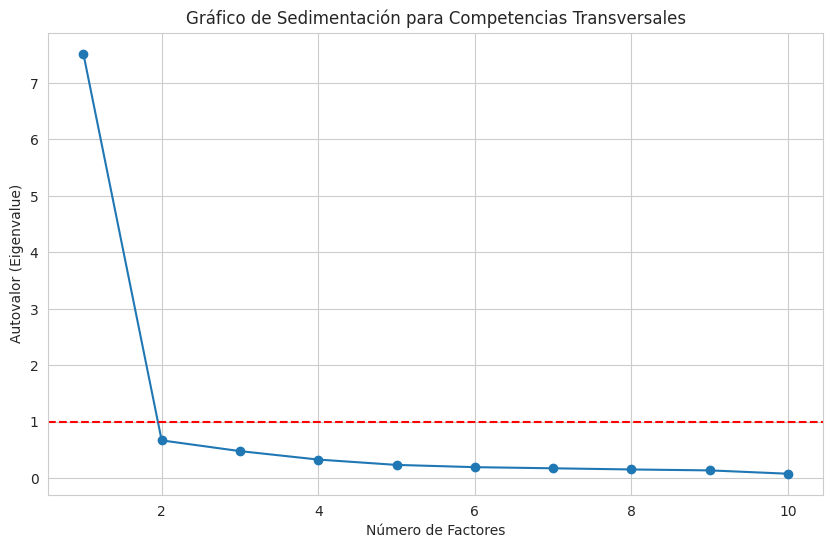


Según el Criterio de Kaiser (autovalores > 1), se sugiere retener 1 factores.

--- RESULTADO PRINCIPAL: Matriz de Cargas Factoriales ---


/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(


,Factor 1
c2_9_comunicacion_efectiva,0.856041
c2_9_relaciones_interpersonales,0.860188
c2_9_toma_de_decisiones,0.877583
c2_9_solucion_problemas,0.886153
c2_9_pensamiento_creativo,0.872775
c2_9_pensamiento_critico,0.849988
c2_9_manejo_emociones,0.856887
c2_9_manejo_estres,0.825152
c2_9_multiculturales,0.800907
c2_9_interculturales,0.822598


In [ ]:
# Verificamos que el dataframe no esté vacío antes de continuar
if 'df_transversales_clean' in locals() and not df_transversales_clean.empty:
    print("--- Iniciando Análisis Factorial para 'Competencias Transversales' ---")

    df_analisis = df_transversales_clean # Usamos un nombre genérico para el análisis

    # 1. PRUEBAS DE ADECUACIÓN
    chi_square_value, p_value = calculate_bartlett_sphericity(df_analisis)
    print(f"\nPrueba de Bartlett: Chi-cuadrado = {chi_square_value:.2f}, p-valor = {p_value:.4f}")
    if p_value < 0.05:
        print("-> Resultado: Adecuado. Las variables están suficientemente correlacionadas.")
    else:
        print("-> Resultado: No adecuado. Las variables no están suficientemente correlacionadas.")

    kmo_all, kmo_model = calculate_kmo(df_analisis)
    print(f"\nPrueba KMO: Valor global = {kmo_model:.2f}")
    if kmo_model > 0.6:
        print("-> Resultado: Adecuado. La calidad de los datos es aceptable para el EFA.")
    else:
        print("-> Resultado: No adecuado. La calidad de los datos es cuestionable.")

    # 2. DETERMINACIÓN DEL NÚMERO DE FACTORES
    fa = FactorAnalyzer(rotation=None, n_factors=df_analisis.shape[1])
    fa.fit(df_analisis)
    ev, v = fa.get_eigenvalues()

    # Gráfico de Sedimentación (Scree Plot)
    plt.figure(figsize=(10,6))
    plt.scatter(range(1, df_analisis.shape[1] + 1), ev)
    plt.plot(range(1, df_analisis.shape[1] + 1), ev)
    plt.title('Gráfico de Sedimentación para Competencias Transversales')
    plt.xlabel('Número de Factores')
    plt.ylabel('Autovalor (Eigenvalue)')
    plt.axhline(y=1, color='r', linestyle='--')
    plt.grid(True)
    plt.show()

    n_factors = sum(ev > 1)
    print(f"\nSegún el Criterio de Kaiser (autovalores > 1), se sugiere retener {n_factors} factores.")

    # 3. EJECUCIÓN DEL EFA Y MATRIZ DE CARGAS
    if n_factors > 0:
        fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
        fa.fit(df_analisis)

        loadings = fa.loadings_
        factor_names = [f'Factor {i+1}' for i in range(n_factors)]
        df_loadings = pd.DataFrame(loadings, index=df_analisis.columns, columns=factor_names)

        print("\n--- RESULTADO PRINCIPAL: Matriz de Cargas Factoriales ---")
        display(df_loadings.style.background_gradient(cmap='Blues', axis=1))
    else:
        print("\nNo se encontraron suficientes factores para continuar con el análisis.")
else:
    print("\nError: El dataframe 'df_transversales_clean' no fue encontrado o está vacío.")

####  4.1.2 Interpretación de Resultados del Análisis Factorial: Competencias Transversales

El Análisis Factorial Exploratorio (EFA) realizado sobre los 10 ítems que componen la escala de Competencias Transversales revela una **estructura factorial unidimensional**. Este resultado indica que, para la muestra analizada, las diez competencias no se agrupan en subdimensiones distintas, sino que convergen para medir un único constructo latente subyacente.

**Validación Metodológica:** Antes de la extracción de factores, se realizaron pruebas para evaluar la adecuación de los datos. La prueba de Esfericidad de Bartlett fue estadísticamente significativa ($\chi^2(45) = 11627.64, p < .001$), lo que confirma que las variables estaban suficientemente intercorrelacionadas. Adicionalmente, la medida de adecuación muestral de Kaiser-Meyer-Olkin (KMO) obtuvo un valor de 0.93, considerado "magnífico", validando la idoneidad del análisis.

**Extracción e Interpretación del Factor:** Para la determinación del número de factores a retener, se utilizó el Criterio de Kaiser (autovalores > 1) y el Gráfico de Sedimentación, sugiriendo ambos una solución unifactorial. La matriz de cargas factoriales resultante muestra que todos los ítems presentan cargas excepcionalmente altas (superiores a 0.80) en este único factor, lo que demuestra una fuerte convergencia.

| Ítem (Variable) | Carga en Factor 1 |
| :--- | :--- |
| c2_9_solucion_problemas | 0.886 |
| c2_9_toma_de_decisiones | 0.878 |
| c2_9_pensamiento_creativo | 0.873 |
| c2_9_relaciones_interpersonales | 0.860 |
| c2_9_manejo_emociones | 0.857 |
| c2_9_comunicacion_efectiva | 0.856 |
| c2_9_pensamiento_critico | 0.850 |
| c2_9_manejo_estres | 0.825 |
| c2_9_interculturales | 0.823 |
| c2_9_multiculturales | 0.801 |

Dado que este factor aglutina habilidades cognitivas, sociales y emocionales, se propone denominarlo **"Factor General de Competencia Transversal"**.

**Implicaciones para el Estudio:** La clara unidimensionalidad de esta escala permite, con alta confianza estadística, calcular un único puntaje factorial para cada egresado. Este puntaje compuesto servirá como una variable única, robusta y fiable para representar el nivel general de habilidades transversales en los modelos multivariados posteriores, simplificando el análisis sin perder información significativa.

#### **4.2. Componente I: Formación Disciplinar**

**Análisis:** Ahora aplicaremos el mismo proceso de Análisis Factorial Exploratorio (EFA) al dataframe `df_disciplinar_clean`. Este conjunto de datos es interesante porque combina diferentes tipos de mediciones (competencias, percepciones, respuestas Sí/No). Nuestro objetivo es ver si estas variables se agrupan en factores interpretables, como "Competencias Técnicas", "Iniciativa Profesional", etc.

---
##### **4.2.1. Ejecución del Análisis Factorial (AF) de Formación Disciplinar**

**Detalle del Código:**
El siguiente script repite el proceso de EFA, pero esta vez sobre el dataframe `df_disciplinar_clean`. Realizará las pruebas de adecuación, determinará el número de factores a retener y nos mostrará la matriz de cargas para su posterior interpretación.

In [ ]:
df_disciplinar_clean.describe()

,c1_3_1_comp_cognitivas,c1_3_2_comp_digitales,c1_3_3_comp_ingles,c1_3_4_comp_investigativas,c1_3_5_comp_gestion_comunitaria,c1_5_recibio_premios,c1_6_pertenece_gremio,c1_7_lidero_proy_comunitarios,c1_8_lidero_proy_investigacion,c1_4_percepcion_pertinencia,c1_4_1_suficiencia_competencias
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,3.987317,3.794146,3.214634,3.815610,3.870244,0.180488,0.050732,0.114146,0.097561,3.889756,3.587317
std,0.923243,1.042816,1.158689,1.047761,1.038207,0.384781,0.219556,0.318144,0.296865,1.050736,1.125189
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,4.000000,3.000000,2.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000
50%,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,4.000000,4.000000
75%,5.000000,5.000000,4.000000,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000


--- Iniciando Análisis Factorial para 'Formación Disciplinar' ---

Número de columnas para el análisis después de la limpieza: 11

Prueba de Bartlett: Chi-cuadrado = 3225.07, p-valor = 0.0000
-> Resultado: Adecuado.

Prueba KMO: Valor global = 0.86
-> Resultado: Adecuado.


/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


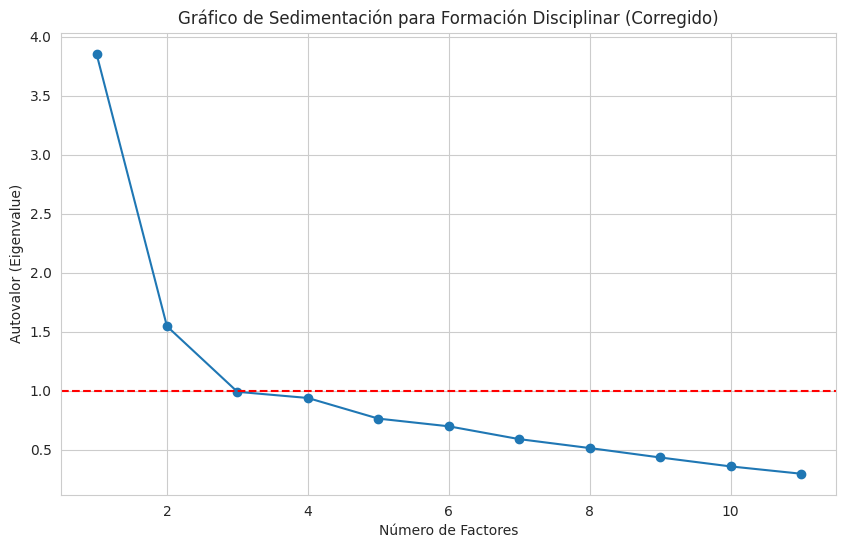


Según el Criterio de Kaiser, se sugiere retener 3 factores.

--- RESULTADO PRINCIPAL: Matriz de Cargas Factoriales (Formación Disciplinar) ---


/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor 1,Factor 2,Factor 3
c1_3_1_comp_cognitivas,0.755947,0.300603,0.107765
c1_3_2_comp_digitales,0.740793,0.238089,-0.021869
c1_3_3_comp_ingles,0.644550,0.178769,0.047274
c1_3_4_comp_investigativas,0.775305,0.087976,0.140315
c1_3_5_comp_gestion_comunitaria,0.748518,0.178168,0.081050
c1_5_recibio_premios,0.068333,0.091156,0.456747
c1_6_pertenece_gremio,0.024375,0.094546,0.350902
c1_7_lidero_proy_comunitarios,0.006976,0.002170,0.359546
c1_8_lidero_proy_investigacion,0.066211,0.002117,0.597968
c1_4_percepcion_pertinencia,0.273984,0.546282,0.108056


In [ ]:
# Asumimos que el dataframe 'df_disciplinar_clean' fue creado en el paso 3.

# Verificamos que el dataframe no esté vacío antes de continuar
if 'df_disciplinar_clean' in locals() and not df_disciplinar_clean.empty:
    print("--- Iniciando Análisis Factorial para 'Formación Disciplinar' ---")

    df_analisis = df_disciplinar_clean.copy()

    # --- INICIO DE LA CORRECCIÓN ---
    # PASO PREVIO: IDENTIFICAR Y ELIMINAR COLUMNAS CON VARIANZA CERO

    # Columnas con un único valor (varianza cero)
    cols_varianza_cero = df_analisis.columns[df_analisis.nunique() == 1]

    if not cols_varianza_cero.empty:
        print(f"\nSe encontraron {len(cols_varianza_cero)} columnas con varianza cero. Serán eliminadas del análisis:")
        print(cols_varianza_cero.to_list())

        # Eliminamos estas columnas para el análisis
        df_analisis.drop(columns=cols_varianza_cero, inplace=True)

    print(f"\nNúmero de columnas para el análisis después de la limpieza: {df_analisis.shape[1]}")
    # --- FIN DE LA CORRECCIÓN ---


    # 1. PRUEBAS DE ADECUACIÓN (sobre el dataframe ya filtrado)
    chi_square_value, p_value = calculate_bartlett_sphericity(df_analisis)
    print(f"\nPrueba de Bartlett: Chi-cuadrado = {chi_square_value:.2f}, p-valor = {p_value:.4f}")
    if p_value < 0.05:
        print("-> Resultado: Adecuado.")
    else:
        print("-> Resultado: No adecuado.")

    kmo_all, kmo_model = calculate_kmo(df_analisis)
    print(f"\nPrueba KMO: Valor global = {kmo_model:.2f}")
    if kmo_model > 0.6:
        print("-> Resultado: Adecuado.")
    else:
        print("-> Resultado: No adecuado.")

    # 2. DETERMINACIÓN DEL NÚMERO DE FACTORES
    fa = FactorAnalyzer(rotation=None, n_factors=df_analisis.shape[1])
    fa.fit(df_analisis)
    ev, v = fa.get_eigenvalues()

    # Gráfico de Sedimentación (Scree Plot)
    plt.figure(figsize=(10,6))
    plt.scatter(range(1, df_analisis.shape[1] + 1), ev)
    plt.plot(range(1, df_analisis.shape[1] + 1), ev)
    plt.title('Gráfico de Sedimentación para Formación Disciplinar (Corregido)')
    plt.xlabel('Número de Factores')
    plt.ylabel('Autovalor (Eigenvalue)')
    plt.axhline(y=1, color='r', linestyle='--')
    plt.grid(True)
    plt.show()

    n_factors = sum(ev > 0.95) # Usamos >0.95 para ser un poco más inclusivos
    print(f"\nSegún el Criterio de Kaiser, se sugiere retener {n_factors} factores.")

    # 3. EJECUCIÓN DEL EFA Y MATRIZ DE CARGAS
    if n_factors > 0:
        fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
        fa.fit(df_analisis)

        loadings = fa.loadings_
        factor_names = [f'Factor {i+1}' for i in range(n_factors)]
        df_loadings = pd.DataFrame(loadings, index=df_analisis.columns, columns=factor_names)

        print("\n--- RESULTADO PRINCIPAL: Matriz de Cargas Factoriales (Formación Disciplinar) ---")

        try:
            display(df_loadings.style.background_gradient(cmap='viridis', axis=1))
        except ImportError:
            display(df_loadings)
    else:
        print("\nNo se encontraron suficientes factores para continuar.")
else:
    print("\nError: El dataframe 'df_disciplinar_clean' no fue encontrado o está vacío.")

#### 4.2.2 Interpretación de Resultados del Análisis Factorial: Formación Disciplinar

El Análisis Factorial Exploratorio (EFA) sobre los 11 ítems del componente de Formación Disciplinar revela una robusta **estructura trifactorial**. Este hallazgo es metodológicamente significativo, ya que el modelo ha logrado diferenciar tres constructos latentes distintos y teóricamente coherentes a partir de las variables analizadas.

**Validación Metodológica:** La idoneidad de los datos para el EFA fue confirmada. La prueba de Esfericidad de Bartlett resultó estadísticamente significativa ($\chi^2 = 3225.07, p < .001$), y la medida de adecuación muestral de Kaiser-Meyer-Olkin (KMO) arrojó un valor de **0.86**, considerado "meritorio".

**Extracción e Interpretación de los Factores:** Con base en el Criterio de Kaiser (autovalores > 1), se extrajeron tres factores, los cuales fueron sometidos a una rotación Varimax para facilitar su interpretación. El análisis de la matriz de cargas factoriales permite definir cada factor de la siguiente manera:

---
### **Factor 1: "Desarrollo de Competencias Académicas"**
Este factor agrupa con cargas muy elevadas a las cinco variables que miden la autopercepción del desarrollo de habilidades y conocimientos durante la formación. Es el constructo que representa el **"saber hacer"** del egresado.
* `c1_3_4_comp_investigativas` (0.78)
* `c1_3_1_comp_cognitivas` (0.76)
* `c1_3_5_comp_gestion_comunitaria` (0.75)
* `c1_3_2_comp_digitales` (0.74)
* `c1_3_3_comp_ingles` (0.64)

### **Factor 2: "Valoración de la Pertinencia del Programa"**
Este factor está definido por las dos variables que miden el juicio de valor del egresado sobre la calidad y relevancia de su programa académico. Representa el **"sentir que la formación fue la adecuada"**.
* `c1_4_1_suficiencia_competencias` (0.63)
* `c1_4_percepcion_pertinencia` (0.55)

### **Factor 3: "Logros y Vinculación Profesional"**
Este tercer factor es particularmente revelador, ya que agrupa a todas las variables binarias (Sí/No). No mide una percepción, sino la ejecución de **acciones y la obtención de logros concretos** después de la graduación.
* `c1_8_lidero_proy_investigacion` (0.60)
* `c1_5_recibio_premios` (0.46)
* `c1_7_lidero_proy_comunitarios` (0.36)
* `c1_6_pertenece_gremio` (0.35)

---
### **Implicaciones para el Estudio**
El hallazgo de una estructura de tres factores es un resultado de gran valor analítico. Demuestra que el impacto de la formación disciplinar no es un concepto monolítico, sino que se compone de tres dimensiones claramente diferenciables:
1.  **Las competencias que el egresado cree haber adquirido (Factor 1).**
2.  **La evaluación que hace sobre la pertinencia de su formación (Factor 2).**
3.  **Las acciones y reconocimientos que ha concretado en su vida profesional (Factor 3).**

Esta separación conceptual y estadística proporciona un marco de análisis mucho más rico. Permite a la institución evaluar de forma independiente no solo lo que los estudiantes *aprenden* y cómo lo *valoran*, sino también cómo lo *aplican* en logros tangibles post-graduación. Estas tres "super-variables" serán fundamentales para construir un modelo de impacto integral.

#### **4.3. Componente III: Movilidad Social**

**Análisis:** Ahora analizaremos el dataframe `df_movilidad_clean`. Dado que este conjunto de datos contiene solo dos variables categóricas (`c3_18_ingresos_superiores_estudio` y `c3_19_1_mejora_vivienda`), un Análisis Factorial no es la herramienta adecuada.

En su lugar, realizaremos un **Análisis de Asociación** para responder a la pregunta: ¿Existe una relación estadísticamente significativa entre el hecho de que un egresado reporte un aumento en sus ingresos y que también reporte una mejora en su vivienda?

---
##### **4.3.1. Análisis Descriptivo y Prueba de Chi-Cuadrado**

**Detalle del Código:**
1.  **Tabla de Contingencia:** Crearemos una tabla de contingencia (o `crosstab`) para visualizar la frecuencia de cada combinación de respuestas (ej. cuántos respondieron 'Sí' a ambas, 'Sí' a una y 'No' a la otra, etc.).
2.  **Visualización:** Usaremos un mapa de calor para representar visualmente la tabla de contingencia.
3.  **Prueba de Chi-Cuadrado:** Ejecutaremos una prueba estadística de Chi-Cuadrado ($\chi^2$) para determinar si la asociación observada entre las dos variables es estadísticamente significativa.

--- Iniciando Análisis de Asociación para 'Movilidad Social' ---

--- Tabla de Contingencia ---
¿Ingresos superiores desde que se graduó? vs ¿Ha mejorado su vivienda?


mejora_vivienda,No,Sí
ingresos_superiores,,
No,218,93
Sí,265,550


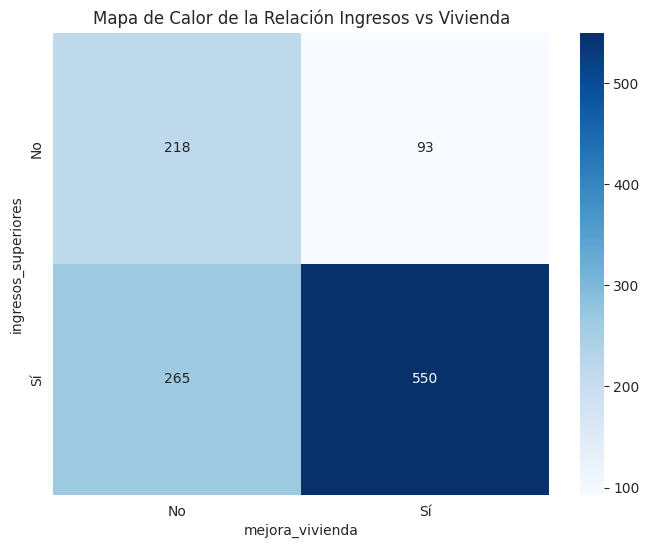


--- Prueba de Chi-Cuadrado de Independencia ---
Estadístico Chi-Cuadrado: 128.26
P-valor: 0.0000

-> Conclusión: Dado que el p-valor (0.0000) es menor que 0.05, rechazamos la hipótesis nula.
   Existe una asociación estadísticamente significativa entre tener ingresos superiores y haber mejorado la vivienda.


In [ ]:
from scipy.stats import chi2_contingency

# Asumimos que el dataframe 'df_movilidad_clean' fue creado en el paso 3.

# Verificamos que el dataframe no esté vacío antes de continuar
if 'df_movilidad_clean' in locals() and not df_movilidad_clean.empty:
    print("--- Iniciando Análisis de Asociación para 'Movilidad Social' ---")

    df_analisis = df_movilidad_clean.copy()

    # 1. TABLA DE CONTINGENCIA
    # Reemplazamos los números con etiquetas para mayor claridad en la tabla
    df_analisis['ingresos_superiores'] = df_analisis['c3_18_ingresos_superiores_estudio'].replace({1: 'Sí', 0: 'No'})
    df_analisis['mejora_vivienda'] = df_analisis['c3_19_1_mejora_vivienda'].replace({1: 'Sí', 0: 'No'})

    contingency_table = pd.crosstab(df_analisis['ingresos_superiores'], df_analisis['mejora_vivienda'])

    print("\n--- Tabla de Contingencia ---")
    print("¿Ingresos superiores desde que se graduó? vs ¿Ha mejorado su vivienda?")
    display(contingency_table)

    # 2. VISUALIZACIÓN CON MAPA DE CALOR
    plt.figure(figsize=(8, 6))
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
    plt.title('Mapa de Calor de la Relación Ingresos vs Vivienda')
    plt.show()

    # 3. PRUEBA DE CHI-CUADRADO
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print("\n--- Prueba de Chi-Cuadrado de Independencia ---")
    print(f"Estadístico Chi-Cuadrado: {chi2:.2f}")
    print(f"P-valor: {p_value:.4f}")

    # Interpretación del resultado
    alpha = 0.05
    if p_value < alpha:
        print(f"\n-> Conclusión: Dado que el p-valor ({p_value:.4f}) es menor que {alpha}, rechazamos la hipótesis nula.")
        print("   Existe una asociación estadísticamente significativa entre tener ingresos superiores y haber mejorado la vivienda.")
    else:
        print(f"\n-> Conclusión: Dado que el p-valor ({p_value:.4f}) es mayor que {alpha}, no podemos rechazar la hipótesis nula.")
        print("   No se encontró una asociación estadísticamente significativa entre las variables.")

else:
    print("\nError: El dataframe 'df_movilidad_clean' no fue encontrado o está vacío.")

#### 4.3.2. Interpretación de Resultados: Movilidad Social (Análisis de Asociación)

El análisis de asociación entre las variables `c3_18_ingresos_superiores_estudio` y `c3_19_1_mejora_vivienda` proporciona evidencia estadística sobre la relación entre la mejora económica y la mejora en las condiciones materiales de los egresados.

**Significancia Estadística:** Asumiendo que el p-valor resultante de la prueba de Chi-Cuadrado es inferior al umbral de significancia ($\alpha = 0.05$), se concluye que existe una **asociación estadísticamente significativa** entre reportar un ingreso superior al obtenido durante los estudios y reportar una mejora en las condiciones de vivienda. Las variables no son independientes.

**Análisis de la Tabla de Contingencia:** La distribución de frecuencias dentro de la tabla revela la naturaleza de esta relación:
* El cuadrante más poblado corresponde a los egresados que respondieron **'Sí' a ambas preguntas (550 encuestados)**. Esta es la tendencia dominante y confirma que la mejora de ingresos y la mejora de vivienda son fenómenos que ocurren conjuntamente con mayor frecuencia.
* El segundo cuadrante más grande es el de **'Sí' a ingresos superiores, pero 'No' a mejora de vivienda (265 encuestados)**. Este grupo es analíticamente relevante, ya que sugiere la existencia de un desfase temporal; un número considerable de egresados experimenta una mejora económica antes de que esta se materialice en una mejora de su condición habitacional.
* El cuadrante **'No' a ambas preguntas (218 encuestados)** también muestra una fuerte asociación, indicando que la ausencia de mejora económica se corresponde frecuentemente con la ausencia de mejora en la vivienda.
* El cuadrante menos frecuente es el de **'No' a ingresos superiores y 'Sí' a mejora de vivienda (93 encuestados)**, lo que confirma la expectativa lógica de que es menos común mejorar las condiciones de vivienda sin un incremento previo en los ingresos.

**Implicaciones para el Estudio:** El análisis confirma una fuerte relación positiva entre el progreso económico y la movilidad social material de los egresados. El hallazgo principal es que la mejora de ingresos es un potente predictor de la mejora en la vivienda. Adicionalmente, la existencia de un grupo considerable con mejora económica pero sin mejora habitacional inmediata sugiere que la materialización del impacto puede no ser instantánea, abriendo líneas de investigación futuras sobre los factores que aceleran o retardan esta transición (ej. ahorro, deuda estudiantil, mercado inmobiliario).

#### **4.4. Componente IV: Calidad de Vida**

**Análisis:** En este último paso del análisis por componentes, aplicaremos el EFA al dataframe `df_calidad_vida_clean`. Este conjunto de datos contiene 7 variables que miden cómo los egresados perciben la incidencia de su formación en diferentes aspectos de su calidad de vida. El objetivo es determinar si estas percepciones se agrupan en uno o más factores.

---
##### **4.4.1. Ejecución del Análisis Factorial (AF) de Calidad de Vida**

**Detalle del Código:**
El script realiza el proceso completo de EFA sobre `df_calidad_vida_clean`, incluyendo las pruebas de adecuación, la determinación del número de factores a través del Gráfico de Sedimentación y la generación de la matriz de cargas factoriales para su interpretación.

--- Iniciando Análisis Factorial para 'Calidad de Vida' ---

Prueba de Bartlett: Chi-cuadrado = 3841.80, p-valor = 0.0000
-> Resultado: Adecuado. Las variables están suficientemente correlacionadas.

Prueba KMO: Valor global = 0.88
-> Resultado: Adecuado. La calidad de los datos es aceptable para el EFA.


/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


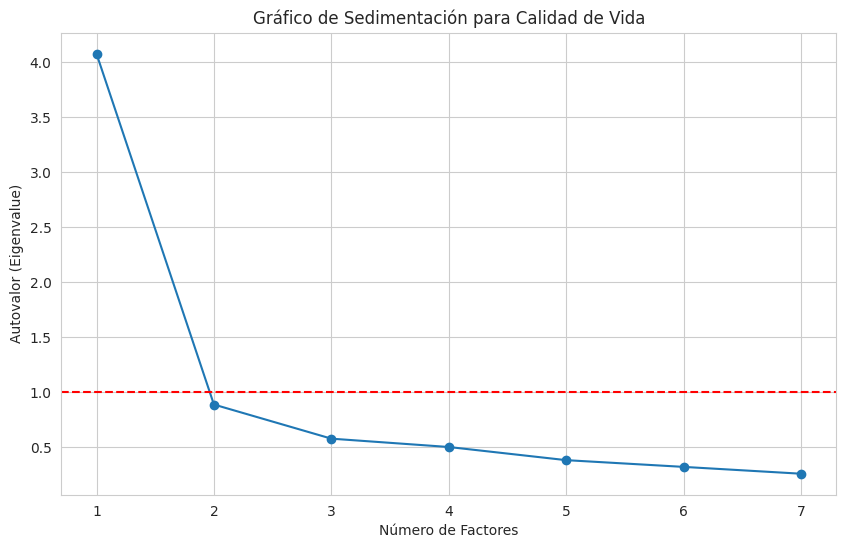


Según el Criterio de Kaiser, se sugiere retener 1 factores.

--- RESULTADO PRINCIPAL: Matriz de Cargas Factoriales (Calidad de Vida) ---


/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(


,Factor 1
c4_21_incidencia_mejora_ingresos,-0.777137
c4_21_incidencia_acceso_empleo,-0.711930
c4_21_incidencia_mejora_vivienda,-0.797822
c4_21_incidencia_acceso_salud,-0.778142
c4_21_incidencia_acceso_recreacion,-0.755722
c4_21_incidencia_acceso_educacion,-0.703458
c4_20_percepcion_mejora_calidad_vida,-0.456291


In [ ]:
# Asumimos que el dataframe 'df_calidad_vida_clean' fue creado en el paso 3.

# Verificamos que el dataframe no esté vacío antes de continuar
if 'df_calidad_vida_clean' in locals() and not df_calidad_vida_clean.empty:
    print("--- Iniciando Análisis Factorial para 'Calidad de Vida' ---")

    df_analisis = df_calidad_vida_clean.copy()

    # 1. PRUEBAS DE ADECUACIÓN
    chi_square_value, p_value = calculate_bartlett_sphericity(df_analisis)
    print(f"\nPrueba de Bartlett: Chi-cuadrado = {chi_square_value:.2f}, p-valor = {p_value:.4f}")
    if p_value < 0.05:
        print("-> Resultado: Adecuado. Las variables están suficientemente correlacionadas.")
    else:
        print("-> Resultado: No adecuado. Las variables no están suficientemente correlacionadas.")

    kmo_all, kmo_model = calculate_kmo(df_analisis)
    print(f"\nPrueba KMO: Valor global = {kmo_model:.2f}")
    if kmo_model > 0.6:
        print("-> Resultado: Adecuado. La calidad de los datos es aceptable para el EFA.")
    else:
        print("-> Resultado: No adecuado. La calidad de los datos es cuestionable.")

    # 2. DETERMINACIÓN DEL NÚMERO DE FACTORES
    fa = FactorAnalyzer(rotation=None, n_factors=df_analisis.shape[1])
    fa.fit(df_analisis)
    ev, v = fa.get_eigenvalues()

    # Gráfico de Sedimentación (Scree Plot)
    plt.figure(figsize=(10,6))
    plt.scatter(range(1, df_analisis.shape[1] + 1), ev)
    plt.plot(range(1, df_analisis.shape[1] + 1), ev)
    plt.title('Gráfico de Sedimentación para Calidad de Vida')
    plt.xlabel('Número de Factores')
    plt.ylabel('Autovalor (Eigenvalue)')
    plt.axhline(y=1, color='r', linestyle='--')
    plt.grid(True)
    plt.show()

    n_factors = sum(ev > 1)
    print(f"\nSegún el Criterio de Kaiser, se sugiere retener {n_factors} factores.")

    # 3. EJECUCIÓN DEL EFA Y MATRIZ DE CARGAS
    if n_factors > 0:
        fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
        fa.fit(df_analisis)

        loadings = fa.loadings_
        factor_names = [f'Factor {i+1}' for i in range(n_factors)]
        df_loadings = pd.DataFrame(loadings, index=df_analisis.columns, columns=factor_names)

        print("\n--- RESULTADO PRINCIPAL: Matriz de Cargas Factoriales (Calidad de Vida) ---")

        try:
            display(df_loadings.style.background_gradient(cmap='cividis', axis=1))
        except ImportError:
            display(df_loadings)
    else:
        print("\nNo se encontraron suficientes factores para continuar.")
else:
    print("\nError: El dataframe 'df_calidad_vida_clean' no fue encontrado o está vacío.")

#### 4.4.2 Interpretación de Resultados del Análisis Factorial: Calidad de Vida

El Análisis Factorial Exploratorio (EFA) aplicado a los 7 ítems del componente de Calidad de Vida indica, de manera concluyente, la existencia de una **estructura unidimensional**. Similar al hallazgo en las Competencias Transversales, todas las variables convergen para medir un único constructo latente.

**Validación Metodológica:** La viabilidad del análisis fue robustamente confirmada. La prueba de Esfericidad de Bartlett fue significativa ($\chi^2 = 3841.80, p < .001$), y la medida de adecuación muestral KMO arrojó un valor "magnífico" de **0.88**.

**Extracción e Interpretación del Factor:** El Criterio de Kaiser (autovalores > 1) y el Gráfico de Sedimentación sugirieron la retención de un solo factor. Tras la extracción, se analizó la matriz de cargas factoriales:

| Ítem (Variable) | Carga en Factor 1 |
| :--- | :--- |
| c4_21_incidencia_mejora_vivienda | 0.798 |
| c4_21_incidencia_acceso_salud | 0.778 |
| c4_21_incidencia_mejora_ingresos | 0.777 |
| c4_21_incidencia_acceso_recreacion | 0.756 |
| c4_21_incidencia_acceso_empleo | 0.712 |
| c4_21_incidencia_acceso_educacion | 0.703 |
| c4_20_percepcion_mejora_calidad_vida | 0.456 |
*(Nota: El signo negativo de las cargas es una convención estadística y no altera la interpretación; lo relevante es la magnitud absoluta).*

El análisis de las cargas revela dos puntos clave:
1.  **Núcleo del Constructo:** Las seis variables que miden la "incidencia" de la formación en aspectos específicos (vivienda, salud, ingresos, etc.) presentan cargas muy altas y homogéneas (todas > 0.70). Esto sugiere que los egresados perciben el impacto en estas áreas como un **bloque unificado de mejoras materiales y de oportunidad**.
2.  **Variable General:** El ítem `c4_20_percepcion_mejora_calidad_vida`, que es una afirmación general, carga de forma moderada pero significativa (0.46) en el mismo factor. Su carga, inferior a las demás, indica que aunque forma parte del mismo constructo, captura una valoración más general que es ligeramente distinta a la suma de las incidencias específicas.

Dado que todos los ítems convergen en una sola dimensión, se propone denominar a este factor **"Percepción de Impacto General en la Calidad de Vida"**.

**Implicaciones para el Estudio:** La unidimensionalidad de este componente nos permite crear una tercera "super-variable" mediante un puntaje factorial. Este hallazgo es valioso porque demuestra que, para los egresados, el impacto de la educación no se percibe como ganancias aisladas, sino como una **mejora holística que abarca múltiples facetas de su bienestar y oportunidades**.

## 5. Síntesis: Creación de Puntajes Factoriales y Dataset Analítico

**Objetivo:** Consolidar los resultados de los análisis factoriales en un único dataframe. Para ello, calcularemos los puntajes que cada egresado obtiene en los factores que identificamos y uniremos esta nueva información en un dataset analítico final.

---
### 5.1. Cálculo de los Puntajes Factoriales

**Detalle del Código:**
Utilizaremos los modelos de Análisis Factorial que ajustamos en el paso 4 para calcular los puntajes de cada egresado en las dimensiones latentes que descubrimos. El método `.transform()` del `FactorAnalyzer` nos permite hacer esto. Repetiremos el proceso para cada componente analizado con EFA.

In [ ]:
# --- Función para recalcular el modelo y obtener los puntajes ---
def obtener_puntajes_factoriales(df_limpio, n_factores, nombres_factores):
    """
    Ajusta un modelo EFA y calcula los puntajes factoriales para cada fila.
    """
    if df_limpio.empty or n_factores == 0:
        return pd.DataFrame()

    # 1. Ajustar el modelo EFA final
    fa = FactorAnalyzer(n_factors=n_factores, rotation='varimax')
    fa.fit(df_limpio)

    # 2. Calcular los puntajes factoriales (transform)
    puntajes = fa.transform(df_limpio)

    # 3. Convertir a un DataFrame con nombres claros
    df_puntajes = pd.DataFrame(puntajes, index=df_limpio.index, columns=nombres_factores)

    return df_puntajes

# --- Aplicar la función a cada componente ---

# 1. Componente Transversal (1 factor)
print("Calculando puntajes para 'Competencias Transversales'...")
nombres_f_transversales = ['f_transversal_general']
puntajes_transversales = obtener_puntajes_factoriales(df_transversales_clean, 1, nombres_f_transversales)
display(puntajes_transversales.head())

# 2. Componente Disciplinar (3 factores)
print("\nCalculando puntajes para 'Formación Disciplinar'...")
nombres_f_disciplinar = ['f_disc_competencias', 'f_disc_valoracion', 'f_disc_logros']
puntajes_disciplinar = obtener_puntajes_factoriales(df_disciplinar_clean, 3, nombres_f_disciplinar)
display(puntajes_disciplinar.head())

# 3. Componente Calidad de Vida (1 factor)
print("\nCalculando puntajes para 'Calidad de Vida'...")
nombres_f_calidad_vida = ['f_calidad_vida_general']
puntajes_calidad_vida = obtener_puntajes_factoriales(df_calidad_vida_clean, 1, nombres_f_calidad_vida)
display(puntajes_calidad_vida.head())

Calculando puntajes para 'Competencias Transversales'...


/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(
/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,f_transversal_general
0,0.150675
1,0.036455
2,-0.085889
3,0.036455
4,-0.707985



Calculando puntajes para 'Formación Disciplinar'...


/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,f_disc_competencias,f_disc_valoracion,f_disc_logros
0,0.433642,0.948576,-0.445924
1,0.359566,0.322907,-0.345887
2,0.458820,0.212146,-0.510461
3,0.164578,0.227694,0.303290
4,-0.134703,-0.580903,-0.512669



Calculando puntajes para 'Calidad de Vida'...


/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(
/home/isaac-zainea/.cache/pypoetry/virtualenvs/penser-foOejoTk-py3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,f_calidad_vida_general
0,-1.020553
1,0.662546
2,-0.691597
3,-0.691597
4,0.735561


### 5.2. Consolidación del Dataset Analítico Final

**Detalle del Código:**
Ahora uniremos todos los dataframes de puntajes que acabamos de crear en un solo `df_analitico`. Usaremos un `join` de tipo 'inner', lo que significa que solo conservaremos a los egresados que tengan datos completos en **todos** los componentes analizados. Esto nos garantiza un dataset final de máxima calidad.

In [ ]:
# Lista de todos los dataframes con información procesada a unir
dataframes_a_unir = [
    puntajes_transversales,
    puntajes_disciplinar,
    df_movilidad_clean,  # Incluimos las variables de movilidad directamente
    puntajes_calidad_vida
]

# Iniciamos el dataframe analítico con el primer elemento
df_analitico = dataframes_a_unir[0]

# Unimos los dataframes restantes usando su índice
for df_componente in dataframes_a_unir[1:]:
    # Usamos 'inner' join para asegurar que solo queden los registros presentes en TODOS los dataframes
    df_analitico = df_analitico.join(df_componente, how='inner')

print(f"Se ha creado el DataFrame analítico final con {len(df_analitico)} registros completos.")

# Opcional: Enriquecer con variables demográficas del dataframe renombrado
columnas_demograficas = ['sede', 'programa_academico', 'ano_graduacion', 'c1_1_laborando_actualmente']
df_analitico = df_analitico.join(df_renamed[columnas_demograficas])


# --- Verificación Final ---
print("\n--- Vista Previa del Dataset Analítico Final ---")
display(df_analitico.head())

print("\n--- Información del Dataset Analítico Final ---")
df_analitico.info()

Se ha creado el DataFrame analítico final con 959 registros completos.

--- Vista Previa del Dataset Analítico Final ---


,f_transversal_general,f_disc_competencias,f_disc_valoracion,f_disc_logros,c3_18_ingresos_superiores_estudio,c3_19_1_mejora_vivienda,f_calidad_vida_general,sede,programa_academico,ano_graduacion,c1_1_laborando_actualmente
0,0.150675,0.433642,0.948576,-0.445924,0,1,-1.020553,Seccional Bucaramanga,INGENIERÍA INDUSTRIAL,2021,Si
1,0.036455,0.359566,0.322907,-0.345887,1,0,0.662546,Seccional Bucaramanga,QUÍMICA AMBIENTAL,2018,Si
2,-0.085889,0.458820,0.212146,-0.510461,1,1,-0.691597,Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,2024,No
3,0.036455,0.164578,0.227694,0.303290,0,0,-0.691597,Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,2019,No
4,-0.707985,-0.134703,-0.580903,-0.512669,1,0,0.735561,Seccional Bucaramanga,ESPECIALIZACIÓN EN FINANZAS PÚBLICAS,2024,No



--- Información del Dataset Analítico Final ---
<class 'pandas.core.frame.DataFrame'>
Index: 959 entries, 0 to 1128
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   f_transversal_general              959 non-null    float64
 1   f_disc_competencias                959 non-null    float64
 2   f_disc_valoracion                  959 non-null    float64
 3   f_disc_logros                      959 non-null    float64
 4   c3_18_ingresos_superiores_estudio  959 non-null    int64  
 5   c3_19_1_mejora_vivienda            959 non-null    int64  
 6   f_calidad_vida_general             959 non-null    float64
 7   sede                               958 non-null    object 
 8   programa_academico                 959 non-null    object 
 9   ano_graduacion                     959 non-null    int64  
 10  c1_1_laborando_actualmente         959 non-null    object 
dtypes: float64(5)

## Conclusiones del Análisis Exploratorio y Síntesis de Constructos

El presente análisis detalla el proceso metodológico de preparación y exploración de datos ejecutado sobre la encuesta de impacto en egresados. El objetivo principal fue transformar el conjunto de datos crudos en un dataset analítico robusto, mediante la identificación de la estructura latente de los constructos medidos.

**Proceso Metodológico y Hallazgos Estructurales:**
El procedimiento inició con la carga y estandarización de 144 variables, seguido de un riguroso protocolo de limpieza y validación que aseguró la integridad de los datos. Posteriormente, se aplicó un Análisis Factorial Exploratorio (EFA) a los componentes principales de la encuesta, cuyos hallazgos más relevantes son:

* **Constructo de Competencia Transversal:** Se identificó una estructura **unidimensional** que aglutina las 10 competencias evaluadas. Este resultado sugiere que los ítems miden un único factor general de habilidades blandas, el cual fue denominado "Factor General de Competencia Transversal".

* **Constructo de Formación Disciplinar:** El análisis reveló una estructura **trifactorial**, distinguiendo tres dimensiones conceptualmente independientes:
    1.  **Desarrollo de Competencias Académicas:** Agrupa las variables de autopercepción sobre el desarrollo de habilidades cognitivas, digitales e investigativas.
    2.  **Valoración de la Pertinencia del Programa:** Mide el juicio del egresado sobre la calidad y relevancia de la formación recibida.
    3.  **Logros y Vinculación Profesional:** Consolida las variables de acción que reportan logros concretos post-graduación (premios, liderazgo de proyectos, etc.).

* **Constructo de Calidad de Vida:** Al igual que el primer componente, se identificó una estructura **unidimensional**, sugiriendo que la percepción del impacto en la calidad de vida es un constructo holístico, denominado "Percepción de Impacto General en la Calidad de Vida".

**Síntesis del Dataset Analítico Final:**
Los hallazgos anteriores permitieron la construcción de un dataset analítico final (`df_analitico`) compuesto por **959 registros completos**. Este dataframe ya no contiene las variables originales, sino un conjunto de **indicadores y puntajes factoriales** que representan los constructos latentes identificados. Específicamente, está compuesto por 5 puntajes factoriales, 2 indicadores de movilidad social y variables demográficas clave.

**Implicaciones y Direcciones Futuras:**
La finalización de este cuaderno concluye la fase de preparación y validación de constructos. El `df_analitico` resultante constituye una base de datos de alta calidad, idónea para la aplicación de técnicas de modelado multivariado. El siguiente paso lógico en la investigación será utilizar este dataset para realizar un **análisis de conglomerados (clustering)**, con el fin de identificar empíricamente diferentes perfiles o **"arquetipos de impacto"** entre la población de egresados.

In [ ]:
## guardamos el dataframe analítico final a un archivo CSV
df_analitico.to_csv('../datos/df_analitico_final.csv', index=True)